Episode 50/500: score=0, eps=0.778
Episode 100/500: score=117, eps=0.606
Episode 150/500: score=328, eps=0.471
Episode 200/500: score=78, eps=0.367
Episode 250/500: score=221, eps=0.286
Episode 300/500: score=427, eps=0.222
Episode 350/500: score=425, eps=0.173
Episode 400/500: score=-521, eps=0.135
Episode 450/500: score=529, eps=0.105
Episode 500/500: score=209, eps=0.082


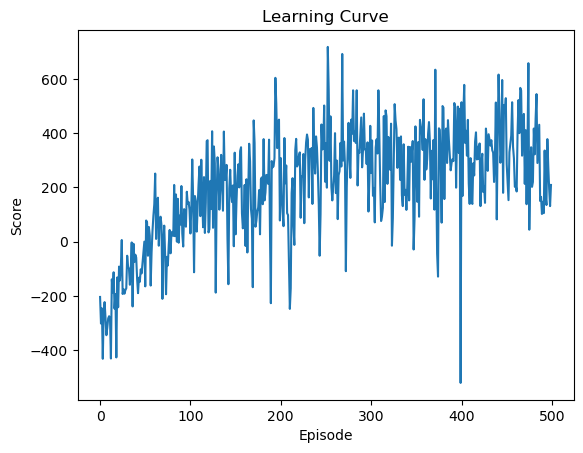

Sample of learned policy:
State (1, 0, -1, 0, -1) -> ACTION: COLLECT_TRASH
State (0, 0, 0, 1, 0) -> ACTION: MOVE_E
State (0, 0, 1, 1, 1) -> ACTION: MOVE_E
State (1, 0, 0, -1, 0) -> ACTION: COLLECT_TRASH
State (1, 1, 0, -1, -1) -> ACTION: MOVE_S


In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Environment constants
GRID_SIZE = 50
TRASH = 1
EMPTY = 0
WALL = -1

# Actions mapping
ACTIONS = {
    0: "MOVE_N",
    1: "MOVE_S",
    2: "MOVE_E",
    3: "MOVE_W",
    4: "MOVE_RANDOM",
    5: "STAY",
    6: "COLLECT_TRASH"
}
NUM_ACTIONS = len(ACTIONS)

# Rewards
REWARD_COLLECT_SUCCESS = 10
REWARD_COLLECT_FAIL = -1
REWARD_WALL_COLLISION = -5

# Q-Learning hyperparameters
ALPHA = 0.1       # learning rate
GAMMA = 0.9       # discount factor
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995

NUM_EPISODES = 500
MAX_STEPS = 1000

class MarvinEnv:
    """
    Grid-based environment for the Marvin trash-collecting robot.
    State: tuple(current_cell, north, south, east, west), each in {-1,0,1}
    """
    def __init__(self, size=GRID_SIZE):
        self.size = size
        self.reset()

    def _generate_grid(self):
        # initialize empty grid
        grid = np.zeros((self.size, self.size), dtype=int)
        # randomly place trash (10%)
        n_trash = self.size * self.size // 10
        n_walls = self.size * self.size // 20
        self._random_place(grid, TRASH, n_trash)
        # randomly place walls (5%)
        self._random_place(grid, WALL, n_walls)
        # ensure start is empty
        grid[0,0] = EMPTY
        return grid

    def _random_place(self, grid, value, count):
        placed = 0
        while placed < count:
            r = random.randrange(self.size)
            c = random.randrange(self.size)
            if (r, c) != (0,0) and grid[r,c] == EMPTY:
                grid[r,c] = value
                placed += 1

    def reset(self):
        """Start new episode: regenerate grid and reset Marvin's position and score."""
        self.grid = self._generate_grid()
        self.pos = (0,0)
        self.score = 0
        return self.state()

    def state(self):
        r, c = self.pos
        curr = self.grid[r,c]
        north = self.grid[r-1,c] if r>0 else WALL
        south = self.grid[r+1,c] if r<self.size-1 else WALL
        east  = self.grid[r,c+1] if c<self.size-1 else WALL
        west  = self.grid[r,c-1] if c>0 else WALL
        return (curr, north, south, east, west)

    def step(self, action_idx):
        """
        Apply action, return (next_state, reward).
        Marvin does not terminate early (fixed-length episodes).
        """
        r, c = self.pos
        reward = 0

        if action_idx == 6:  # COLLECT_TRASH
            if self.grid[r,c] == TRASH:
                reward = REWARD_COLLECT_SUCCESS
                self.grid[r,c] = EMPTY
            else:
                reward = REWARD_COLLECT_FAIL
            self.score += reward
            return self.state(), reward

        # movement actions
        dr, dc = 0, 0
        if action_idx == 0:   dr = -1  # N
        elif action_idx == 1: dr = +1  # S
        elif action_idx == 2: dc = +1  # E
        elif action_idx == 3: dc = -1  # W
        elif action_idx == 4:  # random move
            candidates = []
            for ddr, ddc in [(-1,0),(1,0),(0,1),(0,-1)]:
                nr, nc = r+ddr, c+ddc
                if 0 <= nr < self.size and 0 <= nc < self.size:
                    candidates.append((nr,nc))
            if candidates:
                nr, nc = random.choice(candidates)
                dr, dc = nr-r, nc-c

        nr, nc = r+dr, c+dc
        # check collision
        if not(0 <= nr < self.size and 0 <= nc < self.size) or self.grid[nr,nc] == WALL:
            reward = REWARD_WALL_COLLISION
        else:
            self.pos = (nr, nc)

        self.score += reward
        return self.state(), reward

class QLearningAgent:
    """Tabular Q-learning agent with epsilon-greedy exploration."""
    def __init__(self, n_actions=NUM_ACTIONS,
                 alpha=ALPHA, gamma=GAMMA,
                 eps_start=EPSILON_START, eps_end=EPSILON_END,
                 eps_decay=EPSILON_DECAY):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.q = {}  # dict[state] = np.array of action-values

    def get_q(self, state):
        if state not in self.q:
            self.q[state] = np.zeros(self.n_actions)
        return self.q[state]

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        qs = self.get_q(state)
        max_q = np.max(qs)
        # break ties randomly
        choices = np.flatnonzero(qs == max_q)
        return random.choice(choices)

    def update(self, s, a, r, s_next):
        q_s = self.get_q(s)[a]
        q_next_max = np.max(self.get_q(s_next))
        target = r + self.gamma * q_next_max
        self.q[s][a] += self.alpha * (target - q_s)

    def decay(self):
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

# Training and analysis utilities

def train(env, agent, episodes=NUM_EPISODES, max_steps=MAX_STEPS):
    scores = []
    for ep in range(episodes):
        state = env.reset()
        for step in range(max_steps):
            action = agent.select_action(state)
            next_state, reward = env.step(action)
            agent.update(state, action, reward, next_state)
            state = next_state
        agent.decay()
        scores.append(env.score)
        if (ep+1) % 50 == 0:
            print(f"Episode {ep+1}/{episodes}: score={env.score}, eps={agent.epsilon:.3f}")
    return scores


def plot_learning_curve(scores):
    plt.figure()
    plt.plot(scores)
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.title('Learning Curve')
    # save plot to file without changing logic
    plt.savefig('learning_curve.png')
    plt.show()


def extract_optimal_policy(q_table):
    """Return dict mapping state -> best_action_index."""
    policy = {s: int(np.argmax(q_vals)) for s, q_vals in q_table.items()}
    return policy


def display_sample_policy(policy, env, positions=None):
    """Print optimal action for given positions list or random sample."""
    states = list(policy.keys())
    if not positions:
        sample_states = random.sample(states, min(5, len(states)))
    else:
        sample_states = []
        for pos in positions:
            env.pos = pos
            sample_states.append(env.state())
    for s in sample_states:
        print(f"State {s} -> ACTION: {ACTIONS[policy[s]]}")


def main():
    # initialize environment and agent
    env = MarvinEnv()
    agent = QLearningAgent()

    # train
    scores = train(env, agent)

    # analysis
    plot_learning_curve(scores)
    policy = extract_optimal_policy(agent.q)
    print("Sample of learned policy:")
    display_sample_policy(policy, env)

if __name__ == '__main__':
    main()